# Python Notebook 2
## Classification Modelling & Hyperparameters Tuning

**Student Name:** Sanidu Harsha  
**Module:** 5DATA002W.2 Machine Learning & Data Mining  
**Case Study A:** Predicting Clients' Loan Approval Status

This notebook builds and evaluates three classification models:
- Naive Bayes (NB)
- Logistic Regression (LR)
- K-Nearest Neighbour (KNN)

It also performs hyperparameter tuning for the best-performing model.

In [ ]:
# Import core libraries for data handling.
import pandas as pd
import numpy as np

# Import plotting libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn tools for data splitting, preprocessing, modelling, and evaluation.
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Import classification models.
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics.
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Show plots inside the notebook.
%matplotlib inline

### Load the cleaned classification dataset
This dataset should come from Notebook 1.

In [ ]:
# Import the upload helper for Google Colab.
from google.colab import files

# Upload the cleaned classification dataset created in Notebook 1.
uploaded = files.upload()

Saving classification_dataset_cleaned.csv to classification_dataset_cleaned.csv


In [45]:
# Read the cleaned classification dataset into a DataFrame.
df = pd.read_csv("classification_dataset_cleaned.csv")

# Display the first five rows.
df.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,0,-2426900,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,0,-111739,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,0,-89000,False,False,True,False,False,True,False,False,False
3,40.0,182004,3,35000,8.00,0.19,11,0,35000,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,0,35000,False,False,False,False,True,False,False,False,False


### Check the dataset structure

In [ ]:
# Display the shape of the dataset.
df.shape

(58645, 18)

In [ ]:
# Display the column names.
df.columns.tolist()

['age',
 'income',
 'emplyment_length',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'payment_default_on_file_Y']

In [48]:
print(X.columns)
print(X.shape)
print(y.shape)

Index(['age', 'income', 'emplyment_length', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'credit_history_length',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'payment_default_on_file_Y'],
      dtype='object')
(58645, 16)
(58645,)


In [ ]:
# Display general dataset information.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          58645 non-null  float64
 1   income                       58645 non-null  int64  
 2   emplyment_length             58645 non-null  int64  
 3   loan_amount                  58645 non-null  int64  
 4   loan_interest_rate           58645 non-null  float64
 5   loan_income_ratio            58645 non-null  float64
 6   credit_history_length        58645 non-null  int64  
 7   loan_approval_status         58645 non-null  int64  
 8   max_allowed_loan             58645 non-null  int64  
 9   home_ownership_OTHER         58645 non-null  bool   
 10  home_ownership_OWN           58645 non-null  bool   
 11  home_ownership_RENT          58645 non-null  bool   
 12  loan_intent_EDUCATION        58645 non-null  bool   
 13  loan_intent_HOME

### Define input features and target variable
The target variable is `loan_approval_status`.

In [ ]:
# Remove leakage columns
cols_to_drop = ["loan_approval_status", "max_allowed_loan"]

if "credit_application_acceptance" in df.columns:
    cols_to_drop.append("credit_application_acceptance")

X = df.drop(cols_to_drop, axis=1)
y = df["loan_approval_status"]

print(X.columns.tolist())

['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'payment_default_on_file_Y']


In [ ]:
# Display the shape of the feature matrix and target vector.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (58645, 16)
y shape: (58645,)


### Apply a training-test split
Use the same random state for all models and stratify by the target labels.

In [51]:
# Split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [49]:
# Split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the resulting shapes.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (46916, 16)
X_test shape: (11729, 16)
y_train shape: (46916,)
y_test shape: (11729,)


In [ ]:
# Check the label distribution in the full target vector.
print("Overall target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Overall target distribution:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64

Training target distribution:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64

Test target distribution:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


### Scale the features for Logistic Regression and KNN
Naïve Bayes will be trained without feature scaling in this implementation.

In [ ]:
# Create a StandardScaler object.
scaler = StandardScaler()

# Fit the scaler on the training data and transform both train and test sets.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the scaled training shape.
X_train_scaled.shape

(46916, 16)

### Build the three classification models
- Naïve Bayes
- Logistic Regression
- K-Nearest Neighbour

In [ ]:
# Create the three model objects.
nb_model = GaussianNB()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the Naïve Bayes model on unscaled data.
nb_model.fit(X_train, y_train)

# Train the Logistic Regression model on scaled data.
lr_model.fit(X_train_scaled, y_train)

# Train the KNN model on scaled data.
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

### Generate predictions

In [ ]:
# Generate class predictions for each model.
nb_pred = nb_model.predict(X_test)
lr_pred = lr_model.predict(X_test_scaled)
knn_pred = knn_model.predict(X_test_scaled)

# Generate probability scores for ROC/AUC calculations.
nb_prob = nb_model.predict_proba(X_test)[:, 1]
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

### Evaluate the Naïve Bayes model

In [ ]:
# Display the confusion matrix for Naïve Bayes.
nb_cm = confusion_matrix(y_test, nb_pred)
print("Naïve Bayes Confusion Matrix:")
print(nb_cm)

Naïve Bayes Confusion Matrix:
[[9833  226]
 [1203  467]]


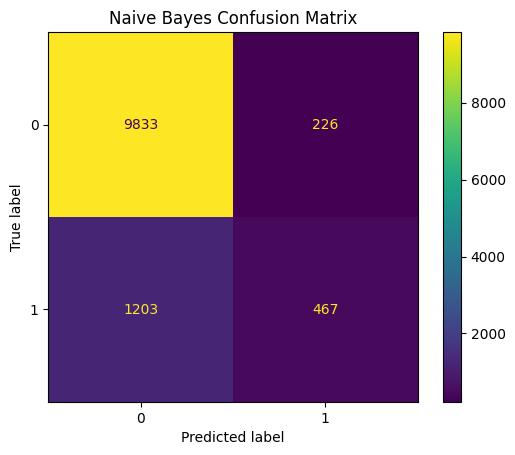

In [ ]:
# Plot the confusion matrix for Naïve Bayes.
disp = ConfusionMatrixDisplay(confusion_matrix=nb_cm)
disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [ ]:
# Display the classification report for Naïve Bayes.
print("Naïve Bayes Classification Report:")
print(classification_report(y_test, nb_pred))

Naïve Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     10059
           1       0.67      0.28      0.40      1670

    accuracy                           0.88     11729
   macro avg       0.78      0.63      0.66     11729
weighted avg       0.86      0.88      0.86     11729



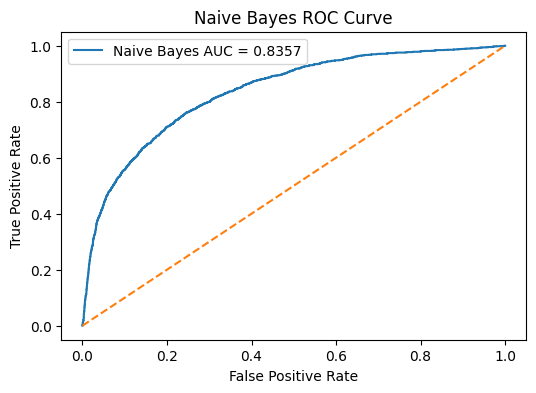

In [ ]:
# Compute ROC curve values and AUC for Naïve Bayes.
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
nb_auc = roc_auc_score(y_test, nb_prob)

# Plot the ROC curve for Naïve Bayes.
plt.figure(figsize=(6, 4))
plt.plot(nb_fpr, nb_tpr, label=f"Naive Bayes AUC = {nb_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.show()

### Evaluate the Logistic Regression model

In [ ]:
# Display the confusion matrix for Logistic Regression.
lr_cm = confusion_matrix(y_test, lr_pred)
print("Logistic Regression Confusion Matrix:")
print(lr_cm)

Logistic Regression Confusion Matrix:
[[9796  263]
 [ 958  712]]


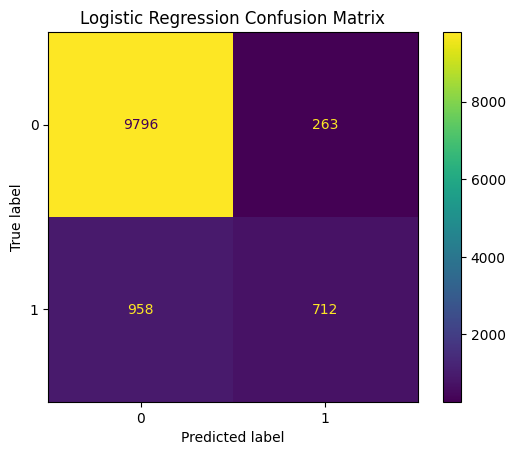

In [ ]:
# Plot the confusion matrix for Logistic Regression.
disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# Display the classification report for Logistic Regression.
print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10059
           1       0.73      0.43      0.54      1670

    accuracy                           0.90     11729
   macro avg       0.82      0.70      0.74     11729
weighted avg       0.89      0.90      0.88     11729



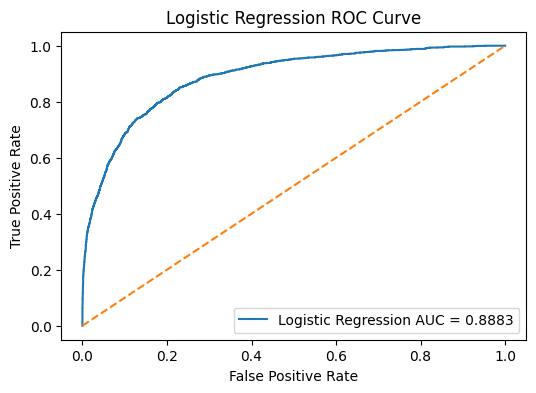

In [ ]:
# Compute ROC curve values and AUC for Logistic Regression.
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_auc = roc_auc_score(y_test, lr_prob)

# Plot the ROC curve for Logistic Regression.
plt.figure(figsize=(6, 4))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression AUC = {lr_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

### Evaluate the K-Nearest Neighbour model

In [ ]:
# Display the confusion matrix for KNN.
knn_cm = confusion_matrix(y_test, knn_pred)
print("K-Nearest Neighbour Confusion Matrix:")
print(knn_cm)

K-Nearest Neighbour Confusion Matrix:
[[9851  208]
 [ 745  925]]


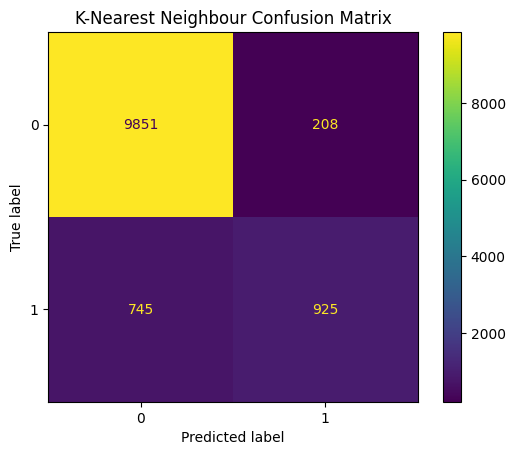

In [ ]:
# Plot the confusion matrix for KNN.
disp = ConfusionMatrixDisplay(confusion_matrix=knn_cm)
disp.plot()
plt.title("K-Nearest Neighbour Confusion Matrix")
plt.show()

In [ ]:
# Display the classification report for KNN.
print("K-Nearest Neighbour Classification Report:")
print(classification_report(y_test, knn_pred))

K-Nearest Neighbour Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059
           1       0.82      0.55      0.66      1670

    accuracy                           0.92     11729
   macro avg       0.87      0.77      0.81     11729
weighted avg       0.91      0.92      0.91     11729



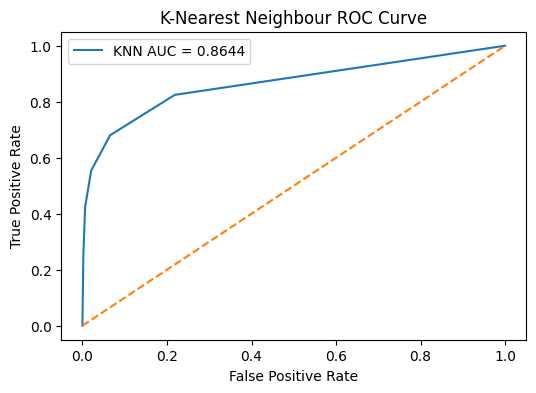

In [ ]:
# Compute ROC curve values and AUC for KNN.
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_prob)
knn_auc = roc_auc_score(y_test, knn_prob)

# Plot the ROC curve for KNN.
plt.figure(figsize=(6, 4))
plt.plot(knn_fpr, knn_tpr, label=f"KNN AUC = {knn_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("K-Nearest Neighbour ROC Curve")
plt.legend()
plt.show()

### Compare the three models
Create a summary table for easier comparison.

In [ ]:
# Create a summary comparison table using AUC.
results_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "K-Nearest Neighbour"],
    "AUC": [nb_auc, lr_auc, knn_auc]
})

# Sort the models by AUC in descending order.
results_df = results_df.sort_values(by="AUC", ascending=False)

# Display the results table.
results_df

,Model,AUC
1,Logistic Regression,0.888318
2,K-Nearest Neighbour,0.864379
0,Naive Bayes,0.835727


In [ ]:
# Show the best model based on AUC.
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on AUC:", best_model_name)

Best model based on AUC: Logistic Regression


### Hyperparameter tuning
Tune the best-performing model.

In [ ]:
# Display the current best model name.
best_model_name

'Logistic Regression'

In [ ]:
# Tune Logistic Regression if it is the best model.
if best_model_name == "Logistic Regression":
    lr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ])

    lr_param_grid = {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["liblinear", "lbfgs"]
    }

    grid_model = GridSearchCV(
        estimator=lr_pipeline,
        param_grid=lr_param_grid,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid_model.fit(X_train, y_train)

In [53]:
# Tune KNN if it is the best model.
if best_model_name == "K-Nearest Neighbour":
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])

    knn_param_grid = {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    }

    grid_model = GridSearchCV(
        estimator=knn_pipeline,
        param_grid=knn_param_grid,
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    grid_model.fit(X_train, y_train)

In [ ]:
# Tune Naïve Bayes if it is the best model.
if best_model_name == "Naive Bayes":
    nb_param_grid = {
        "var_smoothing": np.logspace(-12, -6, 7)
    }

    grid_model = GridSearchCV(
        estimator=GaussianNB(),
        param_grid=nb_param_grid,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    grid_model.fit(X_train, y_train)

In [ ]:
print(best_model_name)

Logistic Regression


In [ ]:
# Display the best hyperparameters found during tuning.
print("Best hyperparameters:")
print(grid_model.best_params_)

Best hyperparameters:
{'model__C': 0.1, 'model__solver': 'lbfgs'}


In [ ]:
# Display the best cross-validation score.
print("Best cross-validation AUC:")
print(grid_model.best_score_)

Best cross-validation AUC:
0.8860018975949963


In [ ]:
# Use the best estimator to make predictions on the test set.
tuned_pred = grid_model.best_estimator_.predict(X_test)

# Get probabilities from the tuned model.
tuned_prob = grid_model.best_estimator_.predict_proba(X_test)[:, 1]

In [ ]:
# Display the confusion matrix for the tuned best model.
tuned_cm = confusion_matrix(y_test, tuned_pred)
print("Tuned Best Model Confusion Matrix:")
print(tuned_cm)

Tuned Best Model Confusion Matrix:
[[9799  260]
 [ 958  712]]


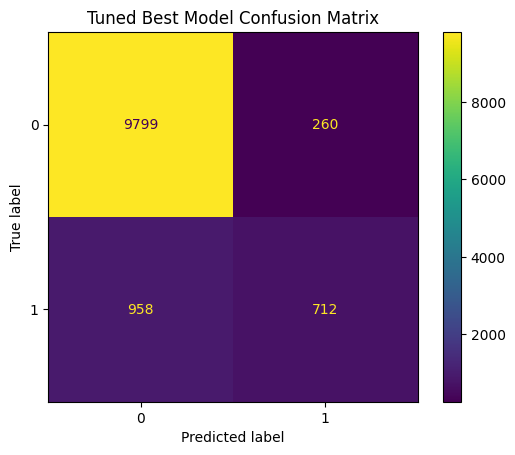

In [ ]:
# Plot the confusion matrix for the tuned best model.
disp = ConfusionMatrixDisplay(confusion_matrix=tuned_cm)
disp.plot()
plt.title("Tuned Best Model Confusion Matrix")
plt.show()

In [ ]:
# Display the classification report for the tuned best model.
print("Tuned Best Model Classification Report:")
print(classification_report(y_test, tuned_pred))

Tuned Best Model Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10059
           1       0.73      0.43      0.54      1670

    accuracy                           0.90     11729
   macro avg       0.82      0.70      0.74     11729
weighted avg       0.89      0.90      0.88     11729



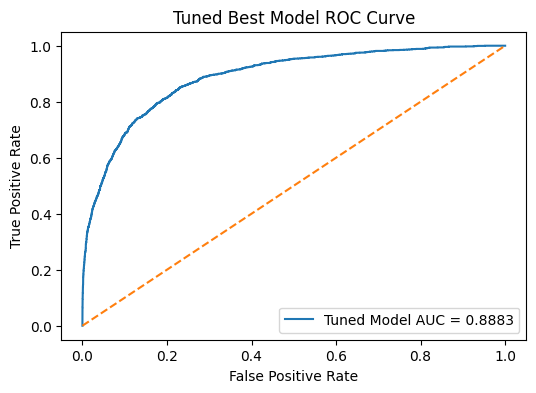

In [ ]:
# Plot the ROC curve for the tuned best model.
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_prob)
tuned_auc = roc_auc_score(y_test, tuned_prob)

plt.figure(figsize=(6, 4))
plt.plot(tuned_fpr, tuned_tpr, label=f"Tuned Model AUC = {tuned_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Best Model ROC Curve")
plt.legend()
plt.show()

### Final summary
This section records the final untuned and tuned AUC values.

In [ ]:
# Display a summary of untuned and tuned best model performance.
print("Untuned model results:")
print(results_df)

print("\nBest untuned model:", best_model_name)
print("Tuned best model AUC:", tuned_auc)

Untuned model results:
                 Model       AUC
1  Logistic Regression  0.888318
2  K-Nearest Neighbour  0.864379
0          Naive Bayes  0.835727

Best untuned model: Logistic Regression
Tuned best model AUC: 0.8882979046380843


### summary
This notebook completed:
- Classification modelling with NB, LR and KNN
- Shared training-test split
- Stratified sampling
- Confusion matrix evaluation
- Classification reports
- ROC/AUC analysis
- Hyperparameter tuning for the best model